# notebooks/04_hmm_analysis.ipynb

In [11]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from hmmlearn.hmm import GaussianHMM

In [12]:
DATA_PATH = os.path.join('..', 'data', 'panel_data_phase4_ready.parquet')
df = pd.read_parquet(DATA_PATH)

stock_ticker = 'AAPL'
df_stock = df.xs(stock_ticker, level='Stock').copy()

X_hmm = np.log1p(df_stock[['rv']].values)

print(f"Data Loaded for {stock_ticker}. Shape: {df_stock.shape}")

Data Loaded for AAPL. Shape: (5322, 34)


In [13]:
print("Fitting HMM with 3 components...")

model_hmm = GaussianHMM(n_components=3, covariance_type="diag", n_iter=100, random_state=42)
model_hmm.fit(X_hmm)
hidden_states = model_hmm.predict(X_hmm)

# Organize the States (Map 0,1,2 -> Low, Mid, High)
df_stock['temp_state'] = hidden_states
state_means = df_stock.groupby('temp_state')['rv'].mean().sort_values()

# Create a mapping dictionary: {Original_ID: 'Label'}
# The state with lowest mean -> 'Low Vol'
# The state with middle mean -> 'Mid Vol'
# The state with highest mean -> 'High Vol'
ordered_states = state_means.index.tolist()
state_map = {
    ordered_states[0]: 'Low Vol',
    ordered_states[1]: 'Mid Vol',
    ordered_states[2]: 'High Vol'
}

df_stock['regime'] = df_stock['temp_state'].map(state_map)

color_map = {
    'Low Vol': 'green',
    'Mid Vol': 'orange',
    'High Vol': 'red'
}

print("Regimes Identified and Labeled:")
print(state_means)
display(df_stock[['rv', 'regime']].head())

Fitting HMM with 3 components...
Regimes Identified and Labeled:
temp_state
2    0.863044
0    2.584323
1    9.107896
Name: rv, dtype: float64


,rv,regime
Date,,
2003-02-04,6.026879,High Vol
2003-02-05,10.062889,High Vol
2003-02-06,6.332991,High Vol
2003-02-07,3.083636,High Vol
2003-02-10,6.420974,High Vol


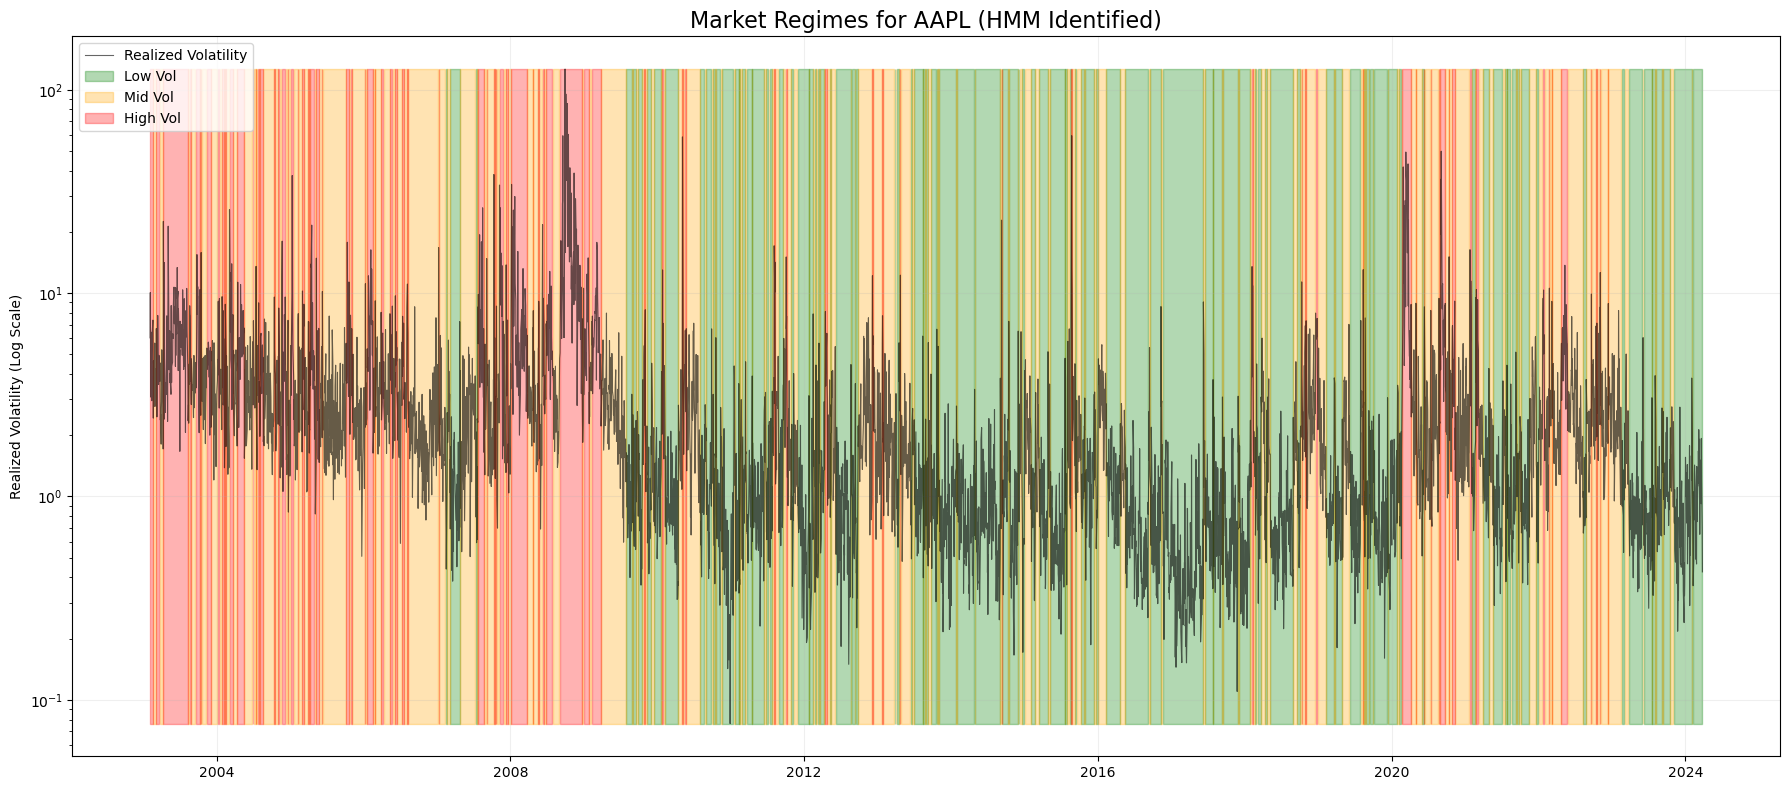

In [14]:
plt.figure(figsize=(18, 8))
dates = df_stock.index
rv_values = df_stock['rv']

plt.plot(dates, rv_values, color='black', linewidth=0.8, label='Realized Volatility', alpha=0.6)

for label, color in color_map.items():
    mask = (df_stock['regime'] == label)
    
    plt.fill_between(dates, rv_values.min(), rv_values.max(), 
                     where=mask, 
                     color=color, 
                     alpha=0.3, 
                     label=label)

plt.title(f'Market Regimes for {stock_ticker} (HMM Identified)', fontsize=16)
plt.ylabel('Realized Volatility (Log Scale)')
plt.yscale('log')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [15]:
# Comparison Analysis

hmm_high_vol_days = df_stock[df_stock['regime'] == 'High Vol']

iso_forest_anomalies = df_stock[df_stock['is_abnormal'] == 1]

overlap_dates = hmm_high_vol_days.index.intersection(iso_forest_anomalies.index)

overlap_count = len(overlap_dates)
hmm_count = len(hmm_high_vol_days)
iso_count = len(iso_forest_anomalies)

precision = overlap_count / hmm_count

recall = overlap_count / iso_count

f1 = 2 * (precision * recall) / (precision + recall)

print("--- Model Agreement Report ---")
print(f"Days in HMM 'High Vol' Regime: {hmm_count}")
print(f"Days labeled 'Abnormal' (IsoForest): {iso_count}")
print(f"Overlapping Days: {overlap_count}")
print("-" * 30)
print(f"Agreement (Precision): {precision:.2%} (Days HMM called High that were Abnormal)")
print(f"Coverage (Recall):     {recall:.2%}    (Anomalies captured by HMM High State)")
print(f"F1-score:     {f1:.2%} (Trade off between precision and recall)")

if recall > 0.80:
    print("\nCONCLUSION: Excellent alignment. The HMM 'High Vol' state captures the vast majority of anomalies.")
elif recall > 0.50:
    print("\nCONCLUSION: Good alignment. The HMM 'High Vol' state captures the most severe anomalies.")
else:
    print("\nCONCLUSION: Divergence. The HMM is defining 'High Volatility' differently than the Isolation Forest.")

--- Model Agreement Report ---
Days in HMM 'High Vol' Regime: 818
Days labeled 'Abnormal' (IsoForest): 418
Overlapping Days: 261
------------------------------
Agreement (Precision): 31.91% (Days HMM called High that were Abnormal)
Coverage (Recall):     62.44%    (Anomalies captured by HMM High State)
F1-score:     42.23% (Trade off between precision and recall)

CONCLUSION: Good alignment. The HMM 'High Vol' state captures the most severe anomalies.
